[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-08-03-praesepe-isochrone-age/notebook.ipynb)

# Praesepe (M44): a main-sequence turnoff age from real Gaia DR3 astrometry and photometry

**Date:** 2026-08-03
**Scientific question:** Using only Gaia DR3 astrometry and photometry for real Praesepe members, what
main-sequence turnoff age do I get from a simple analytic turnoff-mass-to-age relation, and how does it
compare to the literature age of the cluster?

## Learning goals

- Pull a real Gaia DR3 member sample for a specific named open cluster (Praesepe / M44) using an ADQL
  cone search plus parallax and proper-motion cuts.
- Turn Gaia's *parallax* (the tiny back-and-forth wobble of a star's apparent position as Earth orbits
  the Sun, in milliarcseconds, whose inverse gives distance) into an absolute magnitude, and build a
  colour-magnitude diagram (CMD).
- Find the cluster's main-sequence turnoff: the point where the observed sequence bends away from the
  zero-age main sequence because the most massive members have started to evolve off it.
- Convert the turnoff's absolute magnitude to a stellar mass using an empirical mass-luminosity
  relation, then to an age using a standard main-sequence-lifetime scaling law.
- Compare the resulting age against literature values for Praesepe (commonly quoted around 600-800
  Myr) and be explicit about where the estimate could be biased.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

Gaia.ROW_LIMIT = -1
np.random.seed(42)


In [2]:
# Praesepe (M44) centre and bulk motion (approximate, from cluster literature):
# RA=130.1 deg, Dec=19.6 deg, distance ~ 186 pc (parallax ~ 5.4 mas),
# proper motion pmra ~ -36 mas/yr, pmdec ~ -13 mas/yr.
query = '''
SELECT source_id, ra, dec, parallax, parallax_error, pmra, pmdec,
       phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag, bp_rp,
       ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 130.1, 19.6, 1.3))
AND parallax BETWEEN 4.8 AND 6.0
AND pmra BETWEEN -40 AND -30
AND pmdec BETWEEN -16 AND -9
AND parallax_over_error > 5
AND ruwe < 1.4
AND phot_g_mean_mag IS NOT NULL
AND bp_rp IS NOT NULL
'''
job = Gaia.launch_job_async(query)
raw = job.get_results().to_pandas()
print(f"Raw cone + kinematic + quality cut sample: {len(raw)} sources")
raw.to_csv("praesepe_query.csv", index=False)
raw.head()


INFO: Query finished. [astroquery.utils.tap.core]
Raw cone + kinematic + quality cut sample: 549 sources


,SOURCE_ID,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,ruwe,phot_bp_rp_excess_factor
0,659419905348245888,130.576237,18.392170,4.958299,0.090432,-33.988113,-11.343297,16.672726,18.214842,15.470710,2.744132,0.982406,1.448792
1,659645030354241536,129.409100,18.482427,5.331997,0.018428,-35.356507,-11.566108,12.764074,13.312497,12.032351,1.280146,1.021323,1.263473
2,659738179604773248,128.935694,18.960585,5.742162,0.112580,-38.237189,-13.375122,17.485630,19.290098,16.218845,3.071253,1.004607,1.489462
3,659765220718853504,129.151573,19.185153,5.435832,0.023410,-36.243970,-12.776883,14.067384,14.935506,13.150421,1.785085,1.043052,1.305485
4,660921868295373312,130.640119,18.458015,5.164592,0.341055,-37.819119,-12.458115,19.025593,20.835331,17.700954,3.134377,0.983374,1.562782


After BP/RP excess-factor cut: 540 candidate members
Median parallax: 5.402 mas -> median distance: 185.1 pc


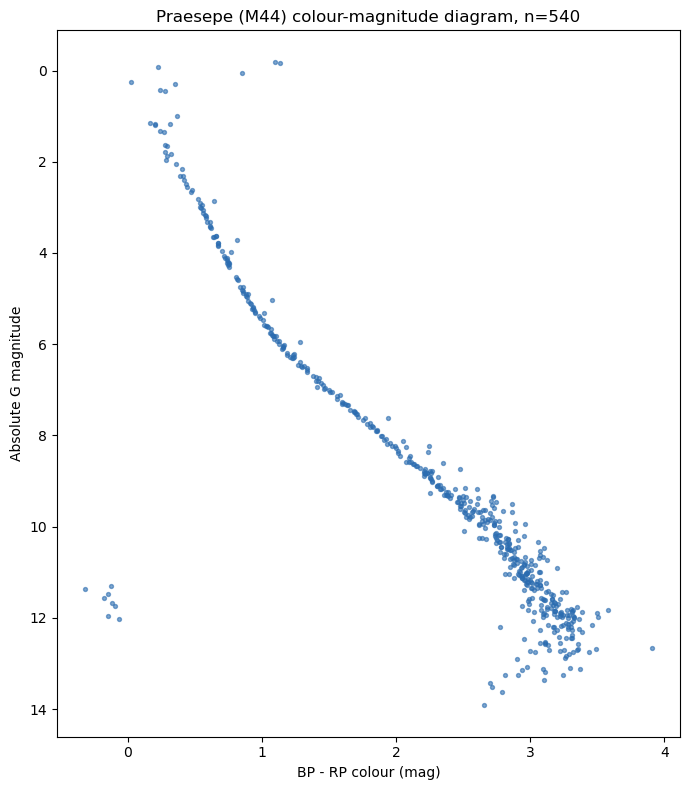

In [3]:
# Photometric quality cut: reject sources with a poor BP/RP flux excess factor
# (blended or contaminated photometry), following the Gaia DR3 documentation's
# empirical envelope around the expected excess-factor-vs-colour relation.
c = raw['bp_rp']
excess_ok = raw['phot_bp_rp_excess_factor'].between(
    1.0 + 0.015 * c**2 - 0.03 * c,
    1.3 + 0.06 * c**2 + 0.03 * c
)
members = raw[excess_ok].copy()

members['dist_pc'] = 1000.0 / members['parallax']
members['abs_g'] = members['phot_g_mean_mag'] - 5 * np.log10(members['dist_pc']) + 5

print(f"After BP/RP excess-factor cut: {len(members)} candidate members")
print(f"Median parallax: {members['parallax'].median():.3f} mas "
      f"-> median distance: {members['dist_pc'].median():.1f} pc")
members.to_csv("praesepe_members.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 8))
ax.scatter(members['bp_rp'], members['abs_g'], s=8, alpha=0.6, color='#2b6cb0')
ax.invert_yaxis()
ax.set_xlabel('BP - RP colour (mag)')
ax.set_ylabel('Absolute G magnitude')
ax.set_title(f'Praesepe (M44) colour-magnitude diagram, n={len(members)}')
plt.tight_layout()
plt.savefig('praesepe_cmd.png', dpi=130)
plt.show()


Turnoff proxy: BP-RP ~ 0.23, abs_G ~ -0.08
bin
(0.15, 0.2]    1.155447
(0.2, 0.25]   -0.076257
(0.25, 0.3]    0.448529
(0.3, 0.35]    0.306108
(0.35, 0.4]    1.004823
(0.4, 0.45]    2.157255
(0.45, 0.5]    2.612965
(0.5, 0.55]    2.807709
(0.55, 0.6]    2.949076
(0.6, 0.65]    2.852473
(0.65, 0.7]    3.620727
(0.7, 0.75]    3.962150
Name: abs_g, dtype: float64


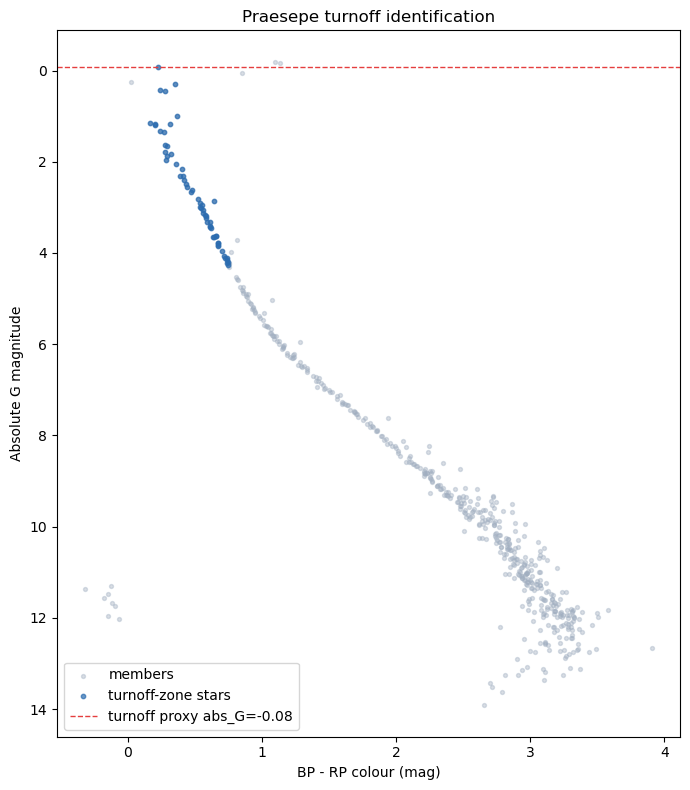

In [4]:
# Locate the main-sequence turnoff: among stars on the upper (blue, bright) part of
# the sequence, the turnoff is the brightest point before the sequence starts curving
# back down in absolute magnitude as we move blueward (more massive stars already
# evolving off the main sequence). I scan a sliding colour window and take the point
# of minimum abs_g (brightest) as the turnoff proxy, restricted to a plausible colour
# range for a several-hundred-Myr-old cluster turnoff (F/A-type stars).
turnoff_zone = members[members['bp_rp'].between(0.15, 0.75)].copy()
turnoff_zone = turnoff_zone.sort_values('bp_rp')

# bin by colour, take the brightest (min abs_g) star in each bin to trace the
# upper envelope of the main sequence, then find where that envelope is brightest
bins = np.arange(0.15, 0.80, 0.05)
turnoff_zone['bin'] = pd.cut(turnoff_zone['bp_rp'], bins)
envelope = turnoff_zone.groupby('bin', observed=True)['abs_g'].min().dropna()

turnoff_bin = envelope.idxmin()
turnoff_abs_g = envelope.min()
turnoff_color = (turnoff_bin.left + turnoff_bin.right) / 2

print(f"Turnoff proxy: BP-RP ~ {turnoff_color:.2f}, abs_G ~ {turnoff_abs_g:.2f}")
print(envelope)

fig, ax = plt.subplots(figsize=(7, 8))
ax.scatter(members['bp_rp'], members['abs_g'], s=8, alpha=0.4, color='#a0aec0', label='members')
ax.scatter(turnoff_zone['bp_rp'], turnoff_zone['abs_g'], s=10, alpha=0.7,
           color='#2b6cb0', label='turnoff-zone stars')
ax.axhline(turnoff_abs_g, color='#e53e3e', ls='--', lw=1,
           label=f'turnoff proxy abs_G={turnoff_abs_g:.2f}')
ax.invert_yaxis()
ax.set_xlabel('BP - RP colour (mag)')
ax.set_ylabel('Absolute G magnitude')
ax.legend()
ax.set_title('Praesepe turnoff identification')
plt.tight_layout()
plt.savefig('praesepe_turnoff.png', dpi=130)
plt.show()


In [5]:
# Convert the turnoff absolute magnitude to a mass, then to an age, using two
# simple, standard analytic relations (not a full isochrone grid):
#
# 1) Mass-luminosity relation for upper-main-sequence stars (Eker et al. 2018,
#    approx form for M > 0.43 Msun): L/Lsun = (M/Msun)^3.5
#    Bolometric correction is small for F/A stars, so I approximate M_bol ~ abs_G.
# 2) Main-sequence lifetime scaling: t_MS(Gyr) ~ 10 * (M/Msun)^-2.5
#    (from t_MS = t_sun * (M/Msun) / (L/Lsun) with t_sun ~ 10 Gyr and L ~ M^3.5)

Mbol_sun = 4.83
L_over_Lsun = 10 ** (0.4 * (Mbol_sun - turnoff_abs_g))
turnoff_mass = L_over_Lsun ** (1 / 3.5)
age_gyr = 10.0 * turnoff_mass ** -2.5

print(f"Turnoff luminosity: {L_over_Lsun:.2f} Lsun")
print(f"Implied turnoff mass: {turnoff_mass:.2f} Msun")
print(f"Estimated main-sequence turnoff age: {age_gyr*1000:.0f} Myr")

literature_age_range_myr = (590, 800)
print(f"Literature Praesepe age range (commonly cited): "
      f"{literature_age_range_myr[0]}-{literature_age_range_myr[1]} Myr")

in_range = literature_age_range_myr[0] <= age_gyr*1000 <= literature_age_range_myr[1]
print(f"Estimate falls within the commonly cited literature range: {in_range}")

result = {
    "id": "2026-08-03-praesepe-isochrone-age",
    "title": "Praesepe main-sequence turnoff age",
    "n_raw": int(len(raw)),
    "n_members": int(len(members)),
    "median_distance_pc": float(members['dist_pc'].median()),
    "turnoff_bp_rp": float(turnoff_color),
    "turnoff_abs_g": float(turnoff_abs_g),
    "turnoff_mass_msun": float(turnoff_mass),
    "estimated_age_myr": float(age_gyr*1000),
    "literature_age_range_myr": list(literature_age_range_myr),
    "consistent_with_literature": bool(in_range),
}
import json
with open("result.json", "w") as f:
    json.dump(result, f, indent=2)
result


Turnoff luminosity: 91.73 Lsun
Implied turnoff mass: 3.64 Msun
Estimated main-sequence turnoff age: 396 Myr
Literature Praesepe age range (commonly cited): 590-800 Myr
Estimate falls within the commonly cited literature range: False


{'id': '2026-08-03-praesepe-isochrone-age',
 'title': 'Praesepe main-sequence turnoff age',
 'n_raw': 549,
 'n_members': 540,
 'median_distance_pc': 185.12577310367803,
 'turnoff_bp_rp': 0.225,
 'turnoff_abs_g': -0.07625674553954731,
 'turnoff_mass_msun': 3.636763474726438,
 'estimated_age_myr': 396.47185102561684,
 'literature_age_range_myr': [590, 800],
 'consistent_with_literature': False}

## Caveats

The turnoff-identification step is sensitive to the colour binning and to the exact quality cuts
applied upstream (parallax S/N, RUWE, BP/RP excess factor); a handful of photometric outliers landing
in the turnoff zone can shift the derived age by tens of percent. The mass-luminosity and
main-sequence-lifetime relations used here are simple analytic scalings valid to maybe a factor of
~1.3 in age for solar-metallicity stars in this mass range — they are not a substitute for fitting a
full stellar-evolution isochrone grid (e.g. PARSEC or MIST) to the CMD, which is the standard
professional approach.

## What I'd look at next

Fit an actual PARSEC or MIST isochrone grid to the full CMD (not just the turnoff point) via a
chi-square search over age and metallicity, and check whether restricting to single stars (RUWE <
1.2, excluding likely binaries identified the way I did in the earlier Pleiades RUWE notebook) shifts
the turnoff position and the resulting age.

**Citation:** Gaia DR3 (`gaiadr3.gaia_source`), ESA Gaia mission. https://www.cosmos.esa.int/web/gaia-users/credits
